### **DBSCAN on Dataset with varying-density clusters:**

Text(0.5, 1.0, 'Data with Varying-Density Clusters')

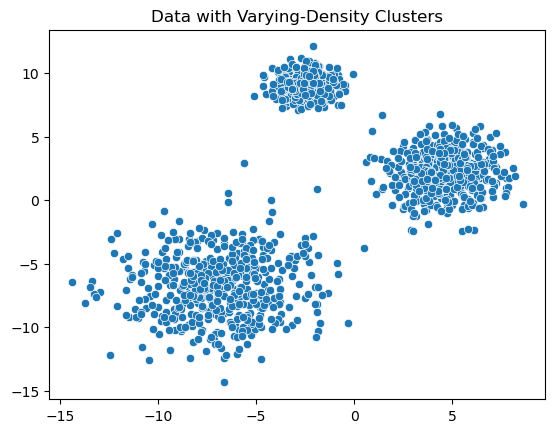

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=1500, centers=3, cluster_std=[0.8, 1.5, 2.5], random_state=42)

ax = sns.scatterplot(x=X[:, 0], y=X[:, 1])
ax.set_title("Data with Varying-Density Clusters")

We run DBSCAN on this dataset to show that DBSCAN algorithm struggle to cluster data with varying-density clusters and the extension on this algorithm that can handle this probelm is `OPTICS` algorithm and there are many other advanced algorithms that can handle this big probelm in DBSCAN algorithm.

array([-1,  0,  1,  2,  3])

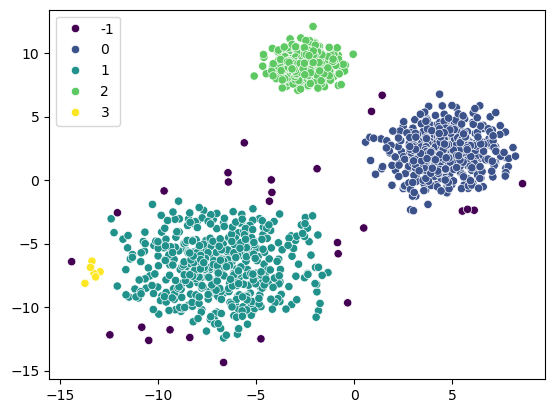

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import numpy as np

# scaling the input data (Standardization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# training the model
best_eps = 0.17
best_min_samples = 4

dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples)
dbscan.fit(X_scaled)

# visualizing the result of clustering
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=dbscan.labels_, palette="viridis")
np.unique(dbscan.labels_)

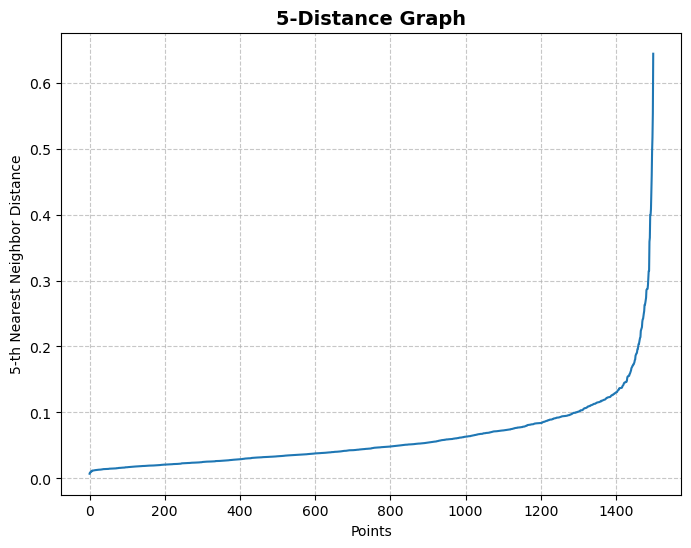

In [9]:
from utils import plot_k_distance_graph

plot_k_distance_graph(X_scaled, n_neighbors=5)

In [13]:
from sklearn.metrics import silhouette_score
from sklearn.model_selection import GridSearchCV
import numpy as np

eps_range = np.arange(0.05, 0.2, 0.01)
min_samples_range = range(4, 6, 1)

best_score = -1
best_eps = 0
best_min_samples = 0
for eps in eps_range:
    for min_samples in min_samples_range:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        dbscan.fit(X_scaled)
        labels = dbscan.labels_
        score = silhouette_score(X_scaled, labels)
        
		# prevents one class clustering
        if len(set(labels)) == 1:
            continue
        
        if score > best_score:
            best_score = score
            best_min_samples = min_samples
            best_eps = eps

print(f"Best Score: {best_score}")
print(f"Best eps: {best_eps}")
print(f"Best min_samples: {best_min_samples}")

Best Score: 0.6517097702330659
Best eps: 0.19
Best min_samples: 4


Even after hyperparameter tuning it's obvious that DBSCAN struggles handling this problem so we can use OPTICS instead.

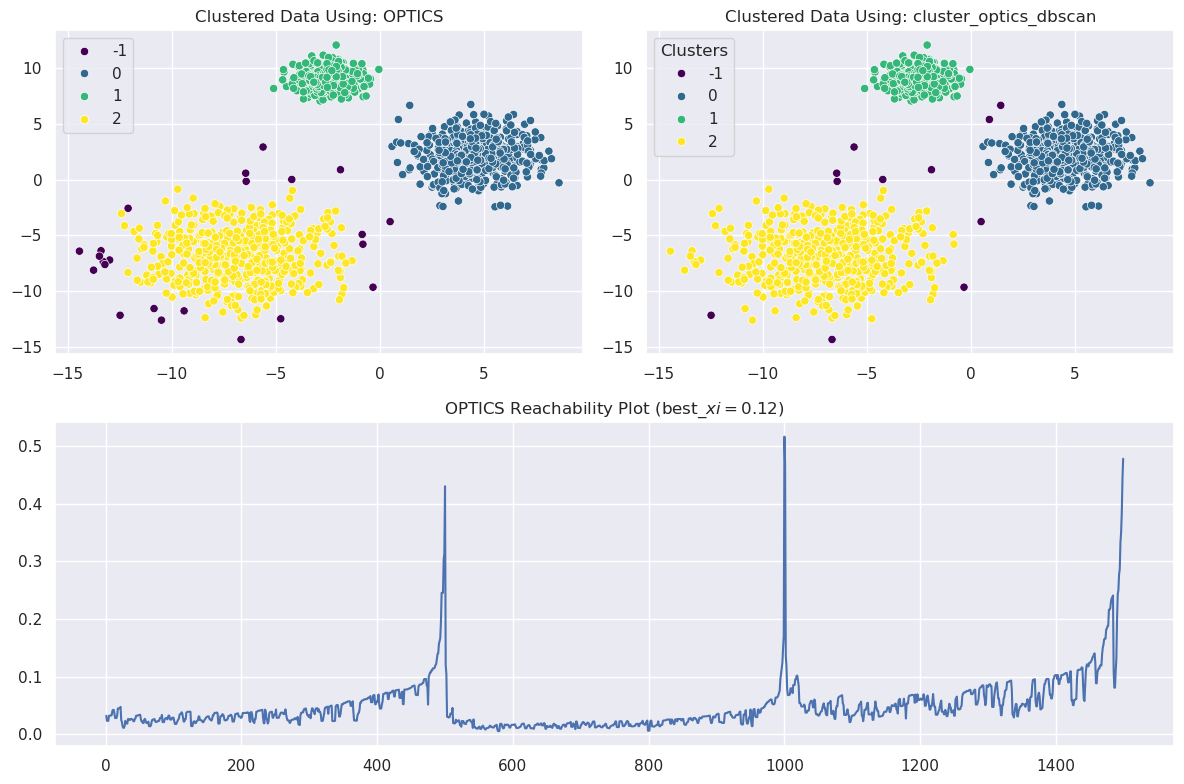

In [14]:
from collections import Counter
from sklearn.cluster import OPTICS, cluster_optics_dbscan

# training the OPTICS model
optics = OPTICS(min_samples=4, xi=0.1, min_cluster_size=0.05)
optics.fit(X_scaled)

labels_02 = cluster_optics_dbscan(
    reachability=optics.reachability_,
    core_distances=optics.core_distances_,
    ordering=optics.ordering_,
    eps=0.25
) # performs dbscan on using the eps extracted from the optics reachability plot

# visualizing the data
sns.set_theme(style="darkgrid")
plt.figure(figsize=(12, 8))

ax1 = plt.subplot(221)
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=optics.labels_, palette="viridis", ax=ax1)
ax1.set_title("Clustered Data Using: OPTICS")

ax2 = plt.subplot(222)
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=labels_02, palette="viridis", ax=ax2)
plt.legend(title="Clusters")
ax2.set_title("Clustered Data Using: cluster_optics_dbscan")

ax3 = plt.subplot(212)
sns.lineplot(x=range(len(optics.reachability_)), y=optics.reachability_[optics.ordering_], ax=ax3)
ax3.set_title("OPTICS Reachability Plot (best_${xi = 0.12}$)")

plt.tight_layout()

We need to tune the hyperparameters.

In [15]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import silhouette_score

# hyperparameter tuning
param_grid = dict(
    min_samples=range(4, 6),
    xi=np.arange(0.1, 0.2, 0.01),
    min_cluster_size=np.arange(0.05, 0.1, 0.02)
)

grid = GridSearchCV(
    estimator=optics,
    param_grid=param_grid,
    scoring=silhouette_score,
    n_jobs=-1,
    cv=5,
    verbose=1
)
grid.fit(X_scaled)

Fitting 5 folds for each of 60 candidates, totalling 300 fits


/home/erfan_taherirani/miniconda3/envs/data-processing/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:927: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/home/erfan_taherirani/miniconda3/envs/data-processing/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 914, in _score
    scores = scorer(estimator, X_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/erfan_taherirani/miniconda3/envs/data-processing/lib/python3.12/site-packages/sklearn/utils/_param_validation.py", line 208, in wrapper
    validate_parameter_constraints(
  File "/home/erfan_taherirani/miniconda3/envs/data-processing/lib/python3.12/site-packages/sklearn/utils/_param_validation.py", line 98, in validate_parameter_constraints
    raise InvalidParameterError(
sklearn.utils._param_validation.InvalidParameterError: The 'X' p

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","OPTICS(min_cl...les=4, xi=0.1)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'min_cluster_size': array([0.05, 0.07, 0.09]), 'min_samples': range(4, 6), 'xi': array([0.1 , ..., 0.18, 0.19])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",<function sil...x77b5d1905b20>
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each 

In [ ]:
print(f"Best Parameters from the Grid Search:\n{grid.best_params_}")

Best Parameters from the Grid Search:
{'min_cluster_size': np.float64(0.05), 'min_samples': 4, 'xi': np.float64(0.1)}
